### Stock Market Prediction And Forecasting Using Stacked LSTM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from math import ceil
import datetime as dt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from sklearn.ensemble import AdaBoostRegressor

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('AAPL_data.csv')

In [4]:
data=df

In [5]:
print(data)

             Date   Adj Close       Close        High         Low        Open  \
0      12-12-1980    0.098834    0.128348    0.128906    0.128348    0.128348   
1      15-12-1980    0.093678    0.121652    0.122210    0.121652    0.122210   
2      16-12-1980    0.086802    0.112723    0.113281    0.112723    0.113281   
3      17-12-1980    0.088951    0.115513    0.116071    0.115513    0.115513   
4      18-12-1980    0.091530    0.118862    0.119420    0.118862    0.118862   
...           ...         ...         ...         ...         ...         ...   
11079  22-11-2024  229.869995  229.869995  230.720001  228.059998  228.059998   
11080  25-11-2024  232.869995  232.869995  233.250000  229.740005  231.460007   
11081  26-11-2024  235.059998  235.059998  235.570007  233.330002  233.330002   
11082  27-11-2024  234.929993  234.929993  235.690002  233.809998  234.470001   
11083  29-11-2024  237.330002  237.330002  237.809998  233.970001  234.809998   

          Volume  
0      4

Text(0.5, 1.0, 'Stock Price of Apple over the Years')

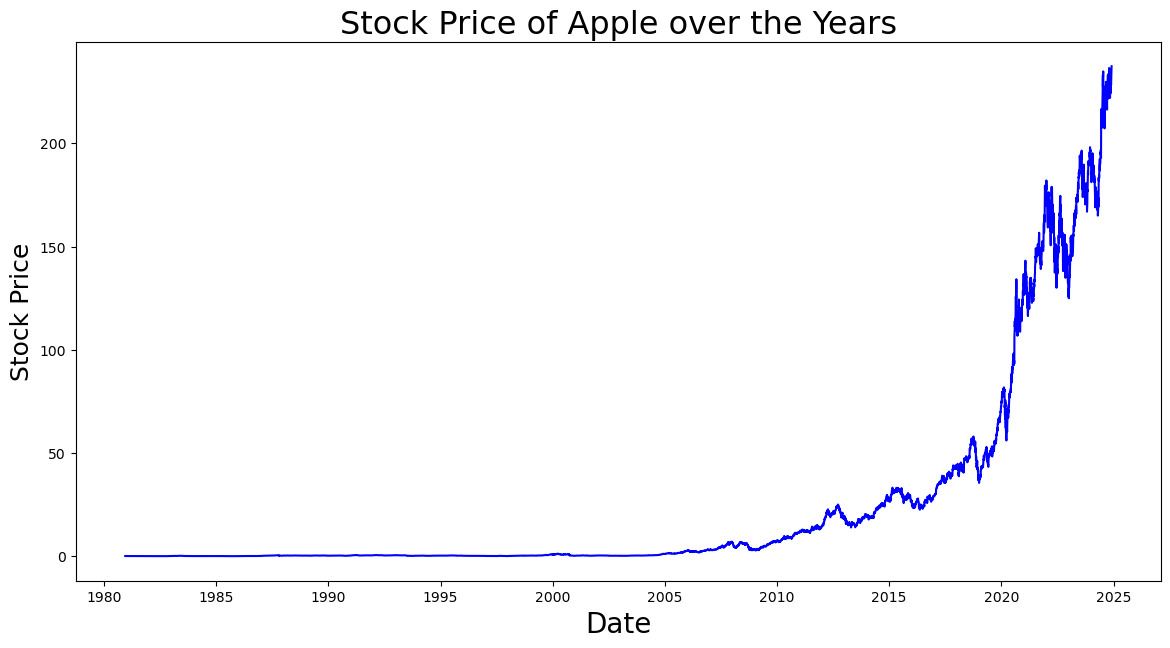

In [6]:
data['Date'] = pd.to_datetime(data.Date,format='%d-%m-%Y')
data.index = data['Date']
plt.figure(figsize=(14,7))
plt.plot(data['Close'], label='Close Price history',color='b')
plt.xlabel('Date',size=20)
plt.ylabel('Stock Price',size=18)
plt.title('Stock Price of Apple over the Years',size=23)

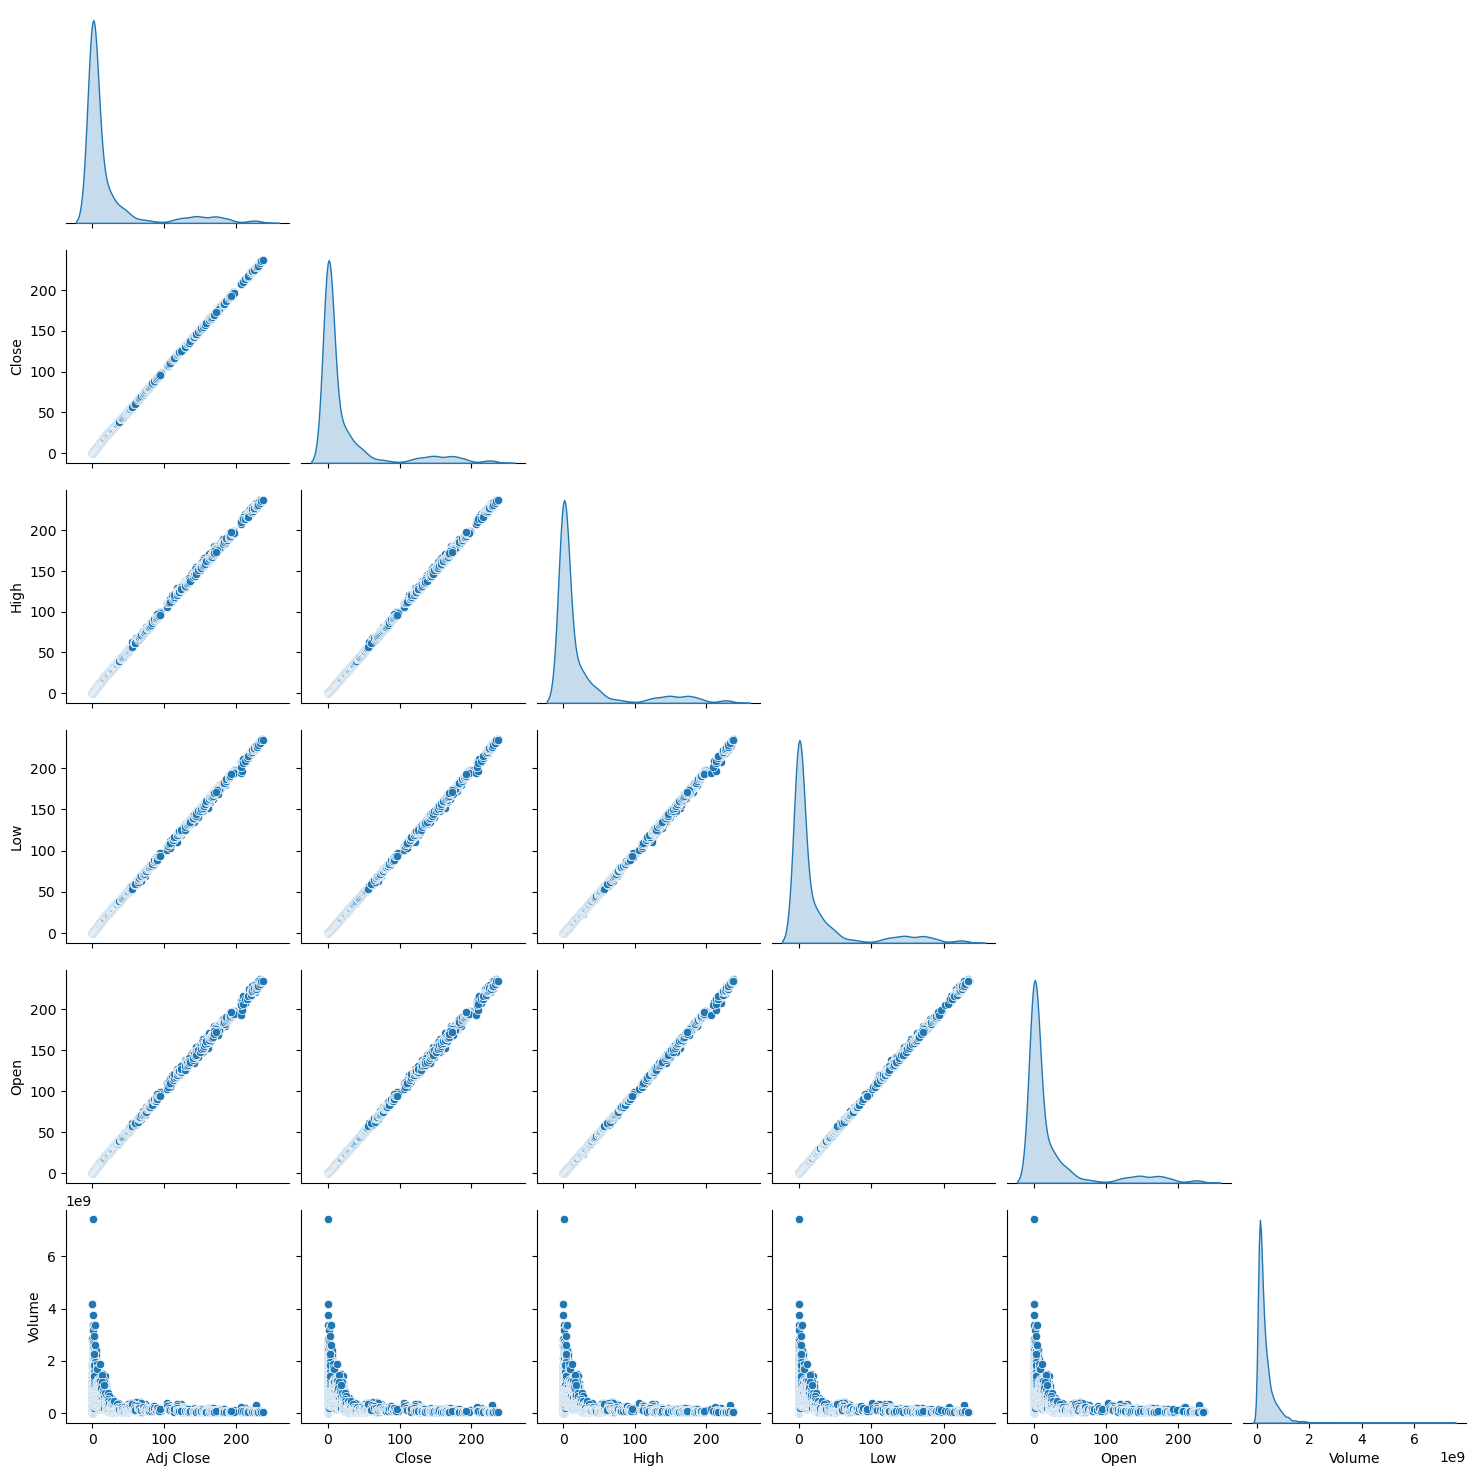

In [7]:
# Plot pairplot

import seaborn as sns 

sns.pairplot(df, diag_kind='kde', corner=True)
plt.show()


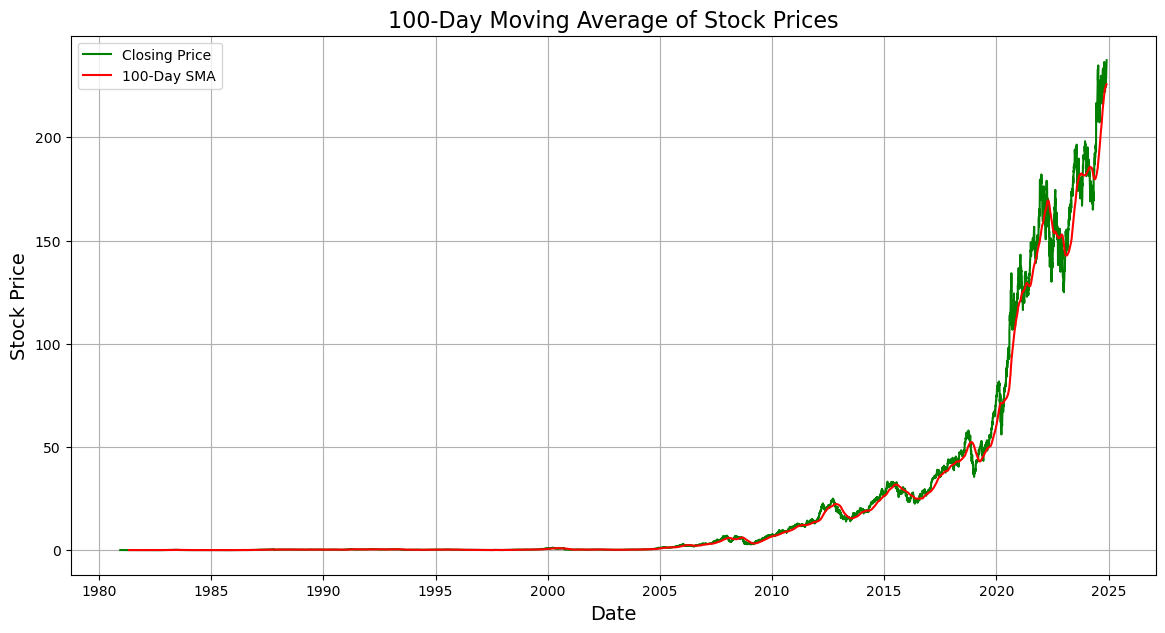

In [8]:
#  Convert the 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')

# Calculate the moving average with a window of 100 days
window_size = 100
data['SMA'] = data['Close'].rolling(window=window_size).mean()
        
# Plotting the Closing Prices and Moving Average
plt.figure(figsize=(14, 7))
plt.plot(data['Date'], data['Close'], label='Closing Price', color='green')
plt.plot(data['Date'], data['SMA'], label=f'{window_size}-Day SMA', color='red')
plt.xlabel('Date', size=14)
plt.ylabel('Stock Price', size=14)
plt.title(f'{window_size}-Day Moving Average of Stock Prices', size=16)
plt.legend()
plt.grid(True)
plt.show()

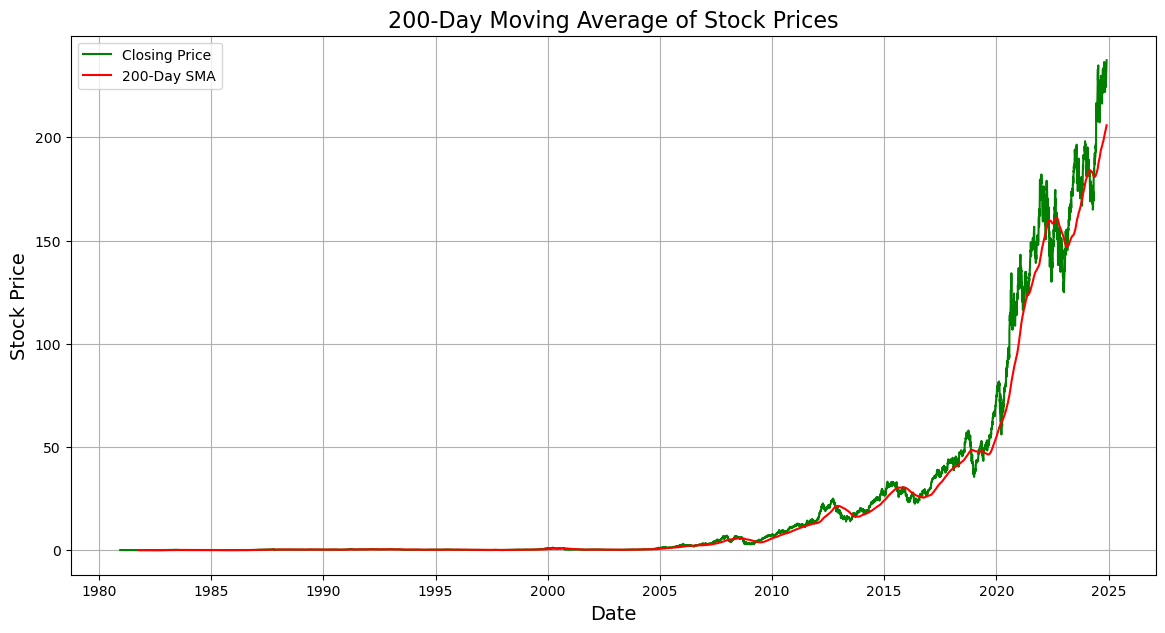

In [9]:
#  Convert the 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')

# Calculate the moving average with a window of 200 days
window_size = 200
data['SMA2'] = data['Close'].rolling(window=window_size).mean()

# Plotting the Closing Prices and Moving Average
plt.figure(figsize=(14, 7))
plt.plot(data['Date'], data['Close'], label='Closing Price', color='green')
plt.plot(data['Date'], data['SMA2'], label=f'{window_size}-Day SMA', color='red')
plt.xlabel('Date', size=14)
plt.ylabel('Stock Price', size=14)
plt.title(f'{window_size}-Day Moving Average of Stock Prices', size=16)
plt.legend()
plt.grid(True)
plt.show()

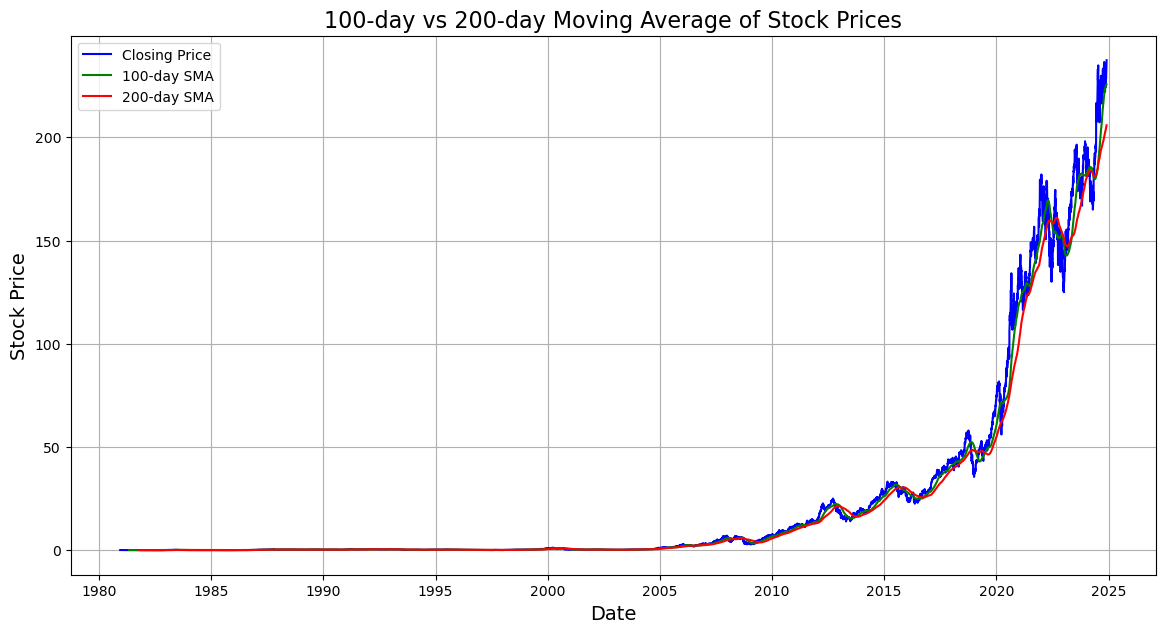

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame containing the stock data with a 'Close' column

# Calculate 100-day SMA
data['SMA'] = data['Close'].rolling(window=100).mean()

# Calculate 200-day SMA
data['SMA2'] = data['Close'].rolling(window=200).mean()

# Plot the closing prices, 100-day SMA, and 200-day SMA
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Closing Price', color='blue')
plt.plot(data['SMA'], label='100-day SMA', color='green')
plt.plot(data['SMA2'], label='200-day SMA', color='red')
plt.xlabel('Date', size=14)
plt.ylabel('Stock Price', size=14)
plt.title('100-day vs 200-day Moving Average of Stock Prices', size=16)
plt.legend()
plt.grid(True)
plt.show()

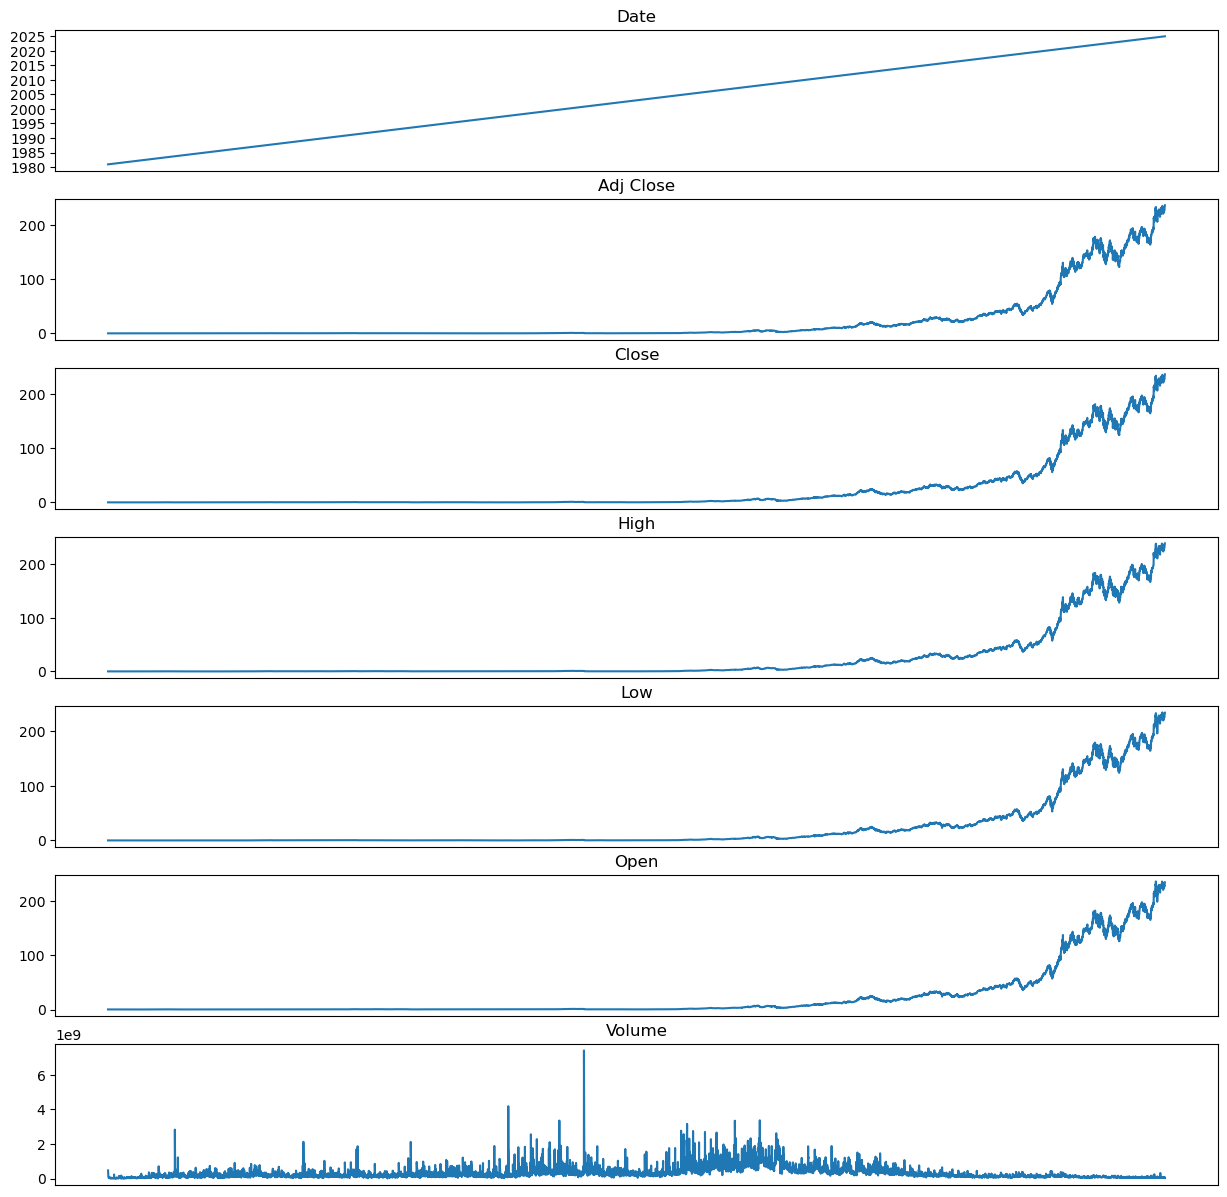

In [11]:
plt.rcParams['figure.figsize'] = [15, 15]
figure, axes = plt.subplots(7)
for ax, col in zip(axes,data.columns):
  ax.plot(data[col])
  ax.set_title(col)
  ax.axes.xaxis.set_visible(False)


In [12]:
import pandas as pd

# Assuming 'df' is your DataFrame
correlations = df.corr()['Close']  # Replace 'Close' with your target variable column name
correlations = correlations.abs().sort_values(ascending=False)

# Print or display the correlations
print(correlations)

Close        1.000000
High         0.999945
Low          0.999945
Open         0.999882
Adj Close    0.999811
SMA          0.995599
SMA2         0.993064
Date         0.678054
Volume       0.262333
Name: Close, dtype: float64


In [13]:
data.drop(['Date', 'Adj Close'], axis=1,inplace=True)
data.drop(['SMA'],axis=1,inplace=True)
data.head(3)

,Close,High,Low,Open,Volume,SMA2
Date,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,469033600,NaN
1980-12-15,0.121652,0.122210,0.121652,0.122210,175884800,NaN
1980-12-16,0.112723,0.113281,0.112723,0.113281,105728000,NaN


In [14]:
data.isnull().sum()

Close       0
High        0
Low         0
Open        0
Volume      0
SMA2      199
dtype: int64

In [15]:
df.shape

(11084, 6)

In [16]:
df.describe()

,Close,High,Low,Open,Volume,SMA2
count,11084.000000,11084.000000,11084.000000,11084.000000,1.108400e+04,10885.000000
mean,23.891777,24.129515,23.631228,23.874671,3.159941e+08,22.332808
std,49.215566,49.687715,48.689050,49.170229,3.349931e+08,45.685937
min,0.049107,0.049665,0.049107,0.049665,0.000000e+00,0.072927
25%,0.300223,0.305804,0.292411,0.299107,1.116140e+08,0.319076
50%,0.539733,0.548192,0.531250,0.539733,2.039756e+08,0.506853
75%,21.060982,21.290535,20.903126,21.126250,3.968776e+08,20.215393
max,237.330002,237.809998,234.449997,236.479996,7.421641e+09,205.826450


In [17]:
# Select features and target variable
X = df[['Open', 'High', 'Low', 'Volume']]   #Features
y = df['Close']  #Target variables

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=60)

X_train.shape
y_train.shape

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Linear Regression

model1 = LinearRegression()
model1.fit(X_train,y_train)
y_pred1 = model1.predict(X_test)
print(f"Predicted Output: {y_pred1}")

accuracy1 = accuracy_score(y_test > y_pred1, y_test > y_pred1.round())
print(f"Accuracy: {accuracy1}")

temp_rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
rmse1 = "{:.20f}".format(temp_rmse1)
print(f"Root Mean Square Error: {rmse1}")

mse1 = mean_squared_error(y_test, y_pred1)
print(f"Mean Square Error: {mse1}")

temp_mae1 = mean_absolute_error(y_test, y_pred1)
mae1 = "{:.20f}".format(temp_mae1)
print(f"Mean Absolute Error: {mae1}")

temp_mape1 = mean_absolute_percentage_error(y_test, y_pred1)
mape1 = "{:.20f}".format(temp_mape1)
print(f"Mean Absolute Percentage Error: {mape1}")

R2_score1 = r2_score(y_test > y_pred1, y_test > y_pred1.round())
print(f"R2 Score: {R2_score1}")

Predicted Output: [ 0.21942024 29.04827214  0.12922013 ...  6.16553218 12.58564362
  4.13830962]
Accuracy: 0.6936259771497294
Root Mean Square Error: 0.35246679325940694083
Mean Square Error: 0.1242328403505695
Mean Absolute Error: 0.11514506544504203578
Mean Absolute Percentage Error: 0.00912401397083909688
R2 Score: -0.3343577653680554


In [19]:
# Random Forest

model2 = RandomForestRegressor()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
print(f"Predicted Output: {y_pred2}")

accuracy2 = accuracy_score(y_test > y_pred2, y_test > y_pred2.round())
print(f"Accuracy: {accuracy2}")

rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f"Root Mean Square Error: {rmse2}")

mse2 = mean_squared_error(y_test, y_pred2)
print(f"Mean Square Error: {mse2}")

mae2 = mean_absolute_error(y_test, y_pred2)
print(f"Mean Absolute Error: {mae2}")

mape2 = mean_absolute_percentage_error(y_test, y_pred2)
print(f"Mean Absolute Percentage Error: {mape2}")

R2_score2 = r2_score(y_test > y_pred2, y_test > y_pred2.round())
print(f"R2 Score: {R2_score2}")

Predicted Output: [ 0.2178014  28.9946751   0.13141155 ...  6.19980383 12.53697843
  4.13328589]
Accuracy: 0.5748647023451593
Root Mean Square Error: 0.44513022385577344
Mean Square Error: 0.198140916189891
Mean Absolute Error: 0.1528178758620662
Mean Absolute Percentage Error: 0.008466183641059133
R2 Score: -0.7015754618132142


#### R2_Score is very less when we use Random Forest model.

#### So we can use another model.

In [21]:
# LSTM

# Reshape the input data for LSTM
n_features = X_train_scaled.shape[1]
n_steps = 10
n_samples_train = X_train_scaled.shape[0] - n_steps + 1
n_samples_test = X_test_scaled.shape[0] - n_steps + 1

# Reshape the input data
X_train_reshaped = np.array([
    X_train_scaled[i:i+n_steps, :]
    for i in range(n_samples_train)
])

X_test_reshaped = np.array([
    X_test_scaled[i:i+n_steps, :]
    for i in range(n_samples_test)
])

y_train_lstm = y_train[n_steps - 1:]
y_test_lstm = y_test[n_steps - 1:]

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

model3 = Sequential([
    Input(shape=(n_steps, n_features)),
    LSTM(64, activation='relu'),
    Dense(1)
])

model3.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history = model3.fit(
    X_train_reshaped,
    y_train_lstm,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred3 = model3.predict(X_test_reshaped).flatten()
print(f"Predicted Output: {y_pred3}")
print(y_pred3)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse3 = mean_squared_error(y_test_lstm, y_pred3)
mae3 = mean_absolute_error(y_test_lstm, y_pred3)
mape3 = mean_absolute_percentage_error(y_test[n_steps-1:], y_pred3)
r2 = r2_score(y_test_lstm, y_pred3)
accuracy3 = r2 * 100

print(f"Accuracy: {accuracy3:.2f}%")
print(f"\nMean Square Error : {mse3}")
print(f"Mean Absolute Error : {mae3}")
print(f"Mean Absolute Percentage Error: {mape3}")
print(f"R2 Score  : {r2}")

Epoch 1/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 2651.8040 - val_loss: 2391.0918
Epoch 2/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2470.3650 - val_loss: 2345.3511
Epoch 3/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 1686.6888 - val_loss: 267.5779
Epoch 4/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 81.8828 - val_loss: 21.9543
Epoch 5/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 25.7888 - val_loss: 11.6122
Epoch 6/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 16.3418 - val_loss: 10.2999
Epoch 7/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 10.4080 - val_loss: 23.1949
Epoch 8/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 9.3173 - val_loss: 6.1600
Epoch 9/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.0107 - val_loss: 10.5273
Epoch 10/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 8.7000 - val_loss: 6.6865
Epoch 11/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 7.4304 - val_loss: 3.7660
Epoc

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
import numpy as np

# ANN Model
model4 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model4.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model4.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)

# Prediction
y_pred4 = model4.predict(X_test_scaled).flatten()

print("Predicted Output:")
print(y_pred4)

# Evaluation
rmse4 = np.sqrt(mean_squared_error(y_test, y_pred4))
mse4 = mean_squared_error(y_test, y_pred4)
mae4 = mean_absolute_error(y_test, y_pred4)
mape4 = mean_absolute_percentage_error(y_test, y_pred4)
r2_4 = r2_score(y_test, y_pred4)
accuracy4 = (1 - mape4) * 100

print(f"Accuracy: {accuracy4:.2f}%")
print(f"RMSE : {rmse4}")
print(f"MSE  : {mse4}")
print(f"MAE  : {mae4}")
print(f"MAPE : {mape4}")
print(f"R2 Score   : {r2_4}")

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted Output:
[ 0.27657968 29.433298    0.19015437 ...  6.319527   12.644659
  4.2033334 ]
Accuracy: 84.80%
RMSE : 0.5752182689178105
MSE  : 0.33087605689680255
MAE  : 0.23317359506463362
MAPE : 0.15203079321063806
R2 Score   : 0.9998596124727913


In [23]:
# SVM

model5 = SVR()

model5.fit(X_train, y_train)

y_pred5 = model5.predict(X_test)
print(f"Predicted Output: {y_pred5}")

accuracy5 = accuracy_score(y_test > y_pred5, y_test > y_pred5.round())
print(f"Accuracy: {accuracy5}")

rmse5 = np.sqrt(mean_squared_error(y_test, y_pred5))
print(f"Root Mean Square Error: {rmse5}")

mse5 = mean_squared_error(y_test, y_pred5)
print(f"Mean Square Error: {mse5}")

mae5 = mean_absolute_error(y_test, y_pred5)
print(f"Mean Absolute Error: {mae5}")

mape5 = mean_absolute_percentage_error(y_test, y_pred5)
print(f"Mean Absolute Percentage Error: {mape5}")

R2_score5 = r2_score(y_test, y_pred5)
print(f"R2 Score: {R2_score5}")

Predicted Output: [0.42154495 2.59908052 0.61177957 ... 1.7431766  2.71086626 1.47876376]
Accuracy: 0.8078773301262778
Root Mean Square Error: 53.69693938010382
Mean Square Error: 2883.361298790545
Mean Absolute Error: 23.162585658354097
Mean Absolute Percentage Error: 1.5861785792453647
R2 Score: -0.22338245499795795


In [24]:
# Decision Tree (CART Algorithm)

model6 = DecisionTreeRegressor()
model6.fit(X_train, y_train)

y_pred6 = model6.predict(X_test)
print(f"Predicted Output: {y_pred6}")

accuracy6 = accuracy_score(y_test > y_pred6, y_test > y_pred6.round())
print(f"Accuracy: {accuracy6}")

rmse6 = np.sqrt(mean_squared_error(y_test, y_pred6))
print(f"Root Mean Square Error: {rmse6}")

mse6 = mean_squared_error(y_test, y_pred6)
print(f"Mean Square Error: {mse6}")

mae6 = mean_absolute_error(y_test, y_pred6)
print(f"Mean Absolute Error: {mae6}")

mape6 = mean_absolute_percentage_error(y_test, y_pred6)
print(f"Mean Absolute Percentage Error: {mape6}")

R2_score6 = r2_score(y_test, y_pred6)
print(f"R2 Score: {R2_score6}")

Predicted Output: [ 0.216518   28.95499992  0.131696   ...  6.20142889 12.50464344
  4.10714292]
Accuracy: 0.552916416115454
Root Mean Square Error: 0.5842274325828507
Mean Square Error: 0.3413216929823494
Mean Absolute Error: 0.18850197823842443
Mean Absolute Percentage Error: 0.010915092820733985
R2 Score: 0.9998551804899095


In [25]:
# KNN

model7 = KNeighborsRegressor()
model7.fit(X_train, y_train)

y_pred7 = model7.predict(X_test)
print(f"Predicted Output: {y_pred7}")

accuracy7 = accuracy_score(y_test > y_pred7, y_test > y_pred7.round())
print(f"Accuracy: {accuracy7}")

rmse7 = np.sqrt(mean_squared_error(y_test, y_pred7))
print(f"Root Mean Square Error: {rmse7}")

mse7 = mean_squared_error(y_test, y_pred7)
print(f"Mean Square Error: {mse7}")

mae7 = mean_absolute_error(y_test, y_pred7)
print(f"Mean Absolute Error: {mae7}")

mape7 = mean_absolute_percentage_error(y_test, y_pred7)
print(f"Mean Absolute Percentage Error: {mape7}")

R2_score7 = r2_score(y_test, y_pred7)
print(f"R2 Score: {R2_score7}")

Predicted Output: [12.27133495  4.40943754 87.80541205 ... 15.42785721  7.9306428
  7.56373215]
Accuracy: 0.9555021046301864
Root Mean Square Error: 42.059831387155114
Mean Square Error: 1769.0294163159183
Mean Absolute Error: 24.597830701115814
Mean Absolute Percentage Error: 64.71998882577648
R2 Score: 0.24941784048916515


In [26]:
# Gradient Boost (XGBoost)

model8 = xgb.XGBRegressor()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model8.fit(X_train, y_train)

pred8 = model8.predict(X_test)
print(f"Predicted Output: {pred8}")

accuracy8 = accuracy_score(y_test > pred8, y_test > pred8.round())
print(f"Accuracy: {accuracy8}")

rmse8 = np.sqrt(mean_squared_error(y_test, pred8))
print(f"Root Mean Square Error: {rmse8}")

mse8 = mean_squared_error(y_test, pred8)
print(f"Mean Square Error: {mse8}")

mae8 = mean_absolute_error(y_test, pred8)
print(f"Mean Absolute Error: {mae8}")

mape8 = mean_absolute_percentage_error(y_test, pred8)
print(f"Mean Absolute Percentage Error: {mape8}")

R2_score8 = r2_score(y_test, pred8)
print(f"R2 Score: {R2_score8}")

Predicted Output: [4.0311599e-01 2.0534590e-01 1.1418253e+02 ... 2.4199436e+01 3.6363778e-01
 2.1882074e+02]
Accuracy: 0.5990076680198466
Root Mean Square Error: 0.8992896421802026
Mean Square Error: 0.8087218605325968
Mean Absolute Error: 0.2649807630873852
Mean Absolute Percentage Error: 0.03001905940653426
R2 Score: 0.9996684930563501


In [27]:
# Xtremum Gradiant Boost

model9 = xgb.XGBRegressor()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model9.fit(X_train, y_train)

pred9 = model9.predict(X_test)

rmse9 = np.sqrt(mean_squared_error(y_test, pred9))
mae9 = mean_absolute_error(y_test, pred9)
mape9 = mean_absolute_percentage_error(y_test, pred9)
mse9 = mean_squared_error(y_test, pred9)
r2_9 = r2_score(y_test, pred9)
accuracy9 = (1 - mape9) * 100

print(f"Accuracy: {accuracy9:.2f}%")
print("Root Mean Square Error:", rmse9)
print("Mean Accuracy Error :", mae9)
print("Mean Accuracy Percentage Error:", mape9)
print("Mean Squeared Error :", mse9)
print("R2 Score  :", r2_9)

Accuracy: 97.00%
Root Mean Square Error: 0.8992896421802026
Mean Accuracy Error : 0.2649807630873852
Mean Accuracy Percentage Error: 0.03001905940653426
Mean Squeared Error : 0.8087218605325968
R2 Score  : 0.9996684930563501


In [29]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
import numpy as np

# AdaBoost Regressor
model10 = AdaBoostRegressor(random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model10.fit(X_train_scaled, y_train)
pred10 = model10.predict(X_test_scaled)

rmse10 = np.sqrt(mean_squared_error(y_test, pred10))
print("Root Mean Squared Error:", rmse10)

mae10 = mean_absolute_error(y_test, pred10)
print("Mean Absolute Error:", mae10)

mape10 = mean_absolute_percentage_error(y_test, pred10)
print("Mean Absolute Percentage Error:", mape10)

mse10 = mean_squared_error(y_test, pred10)
print("Mean Squared Error:", mse10)

r2_10 = r2_score(y_test, pred10)
print("R2 Score:", r2_10)

accuracy10 = r2_10 * 100
print(f"Accuracy (R²-based): {accuracy10:.2f}%")

Root Mean Squared Error: 3.108763052832076
Mean Absolute Error: 2.818111718952553
Mean Absolute Percentage Error: 9.693064479511786
Mean Squared Error: 9.66440771865381
R2 Score: 0.9960384176299033
Accuracy (R²-based): 99.60%


### Comparing all evaluation Metrics

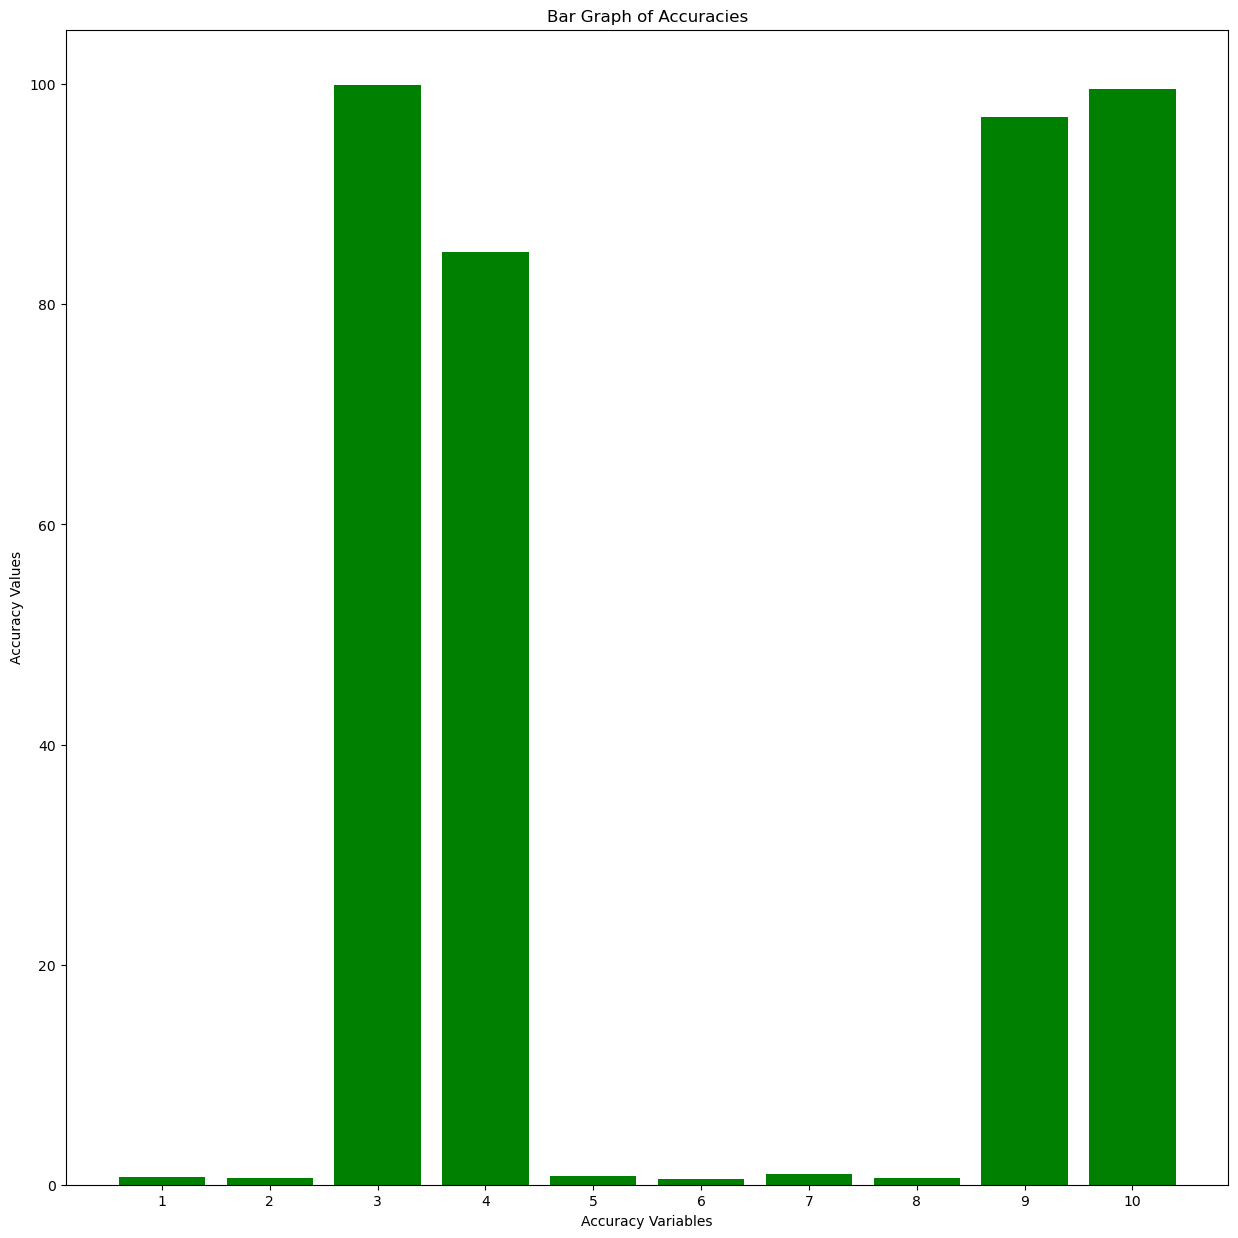

In [30]:
import matplotlib.pyplot as plt

accuracies = [accuracy1, accuracy2,accuracy3, accuracy4, accuracy5, accuracy6, accuracy7, accuracy8, accuracy9, accuracy10]
labels = ['1', '2', '3', '4', '5', '6', '7', '8', '9','10']

# Plotting the bar graph
plt.bar(labels, accuracies, color='green')
plt.xlabel('Accuracy Variables')
plt.ylabel('Accuracy Values')
plt.title('Bar Graph of Accuracies')
plt.show()

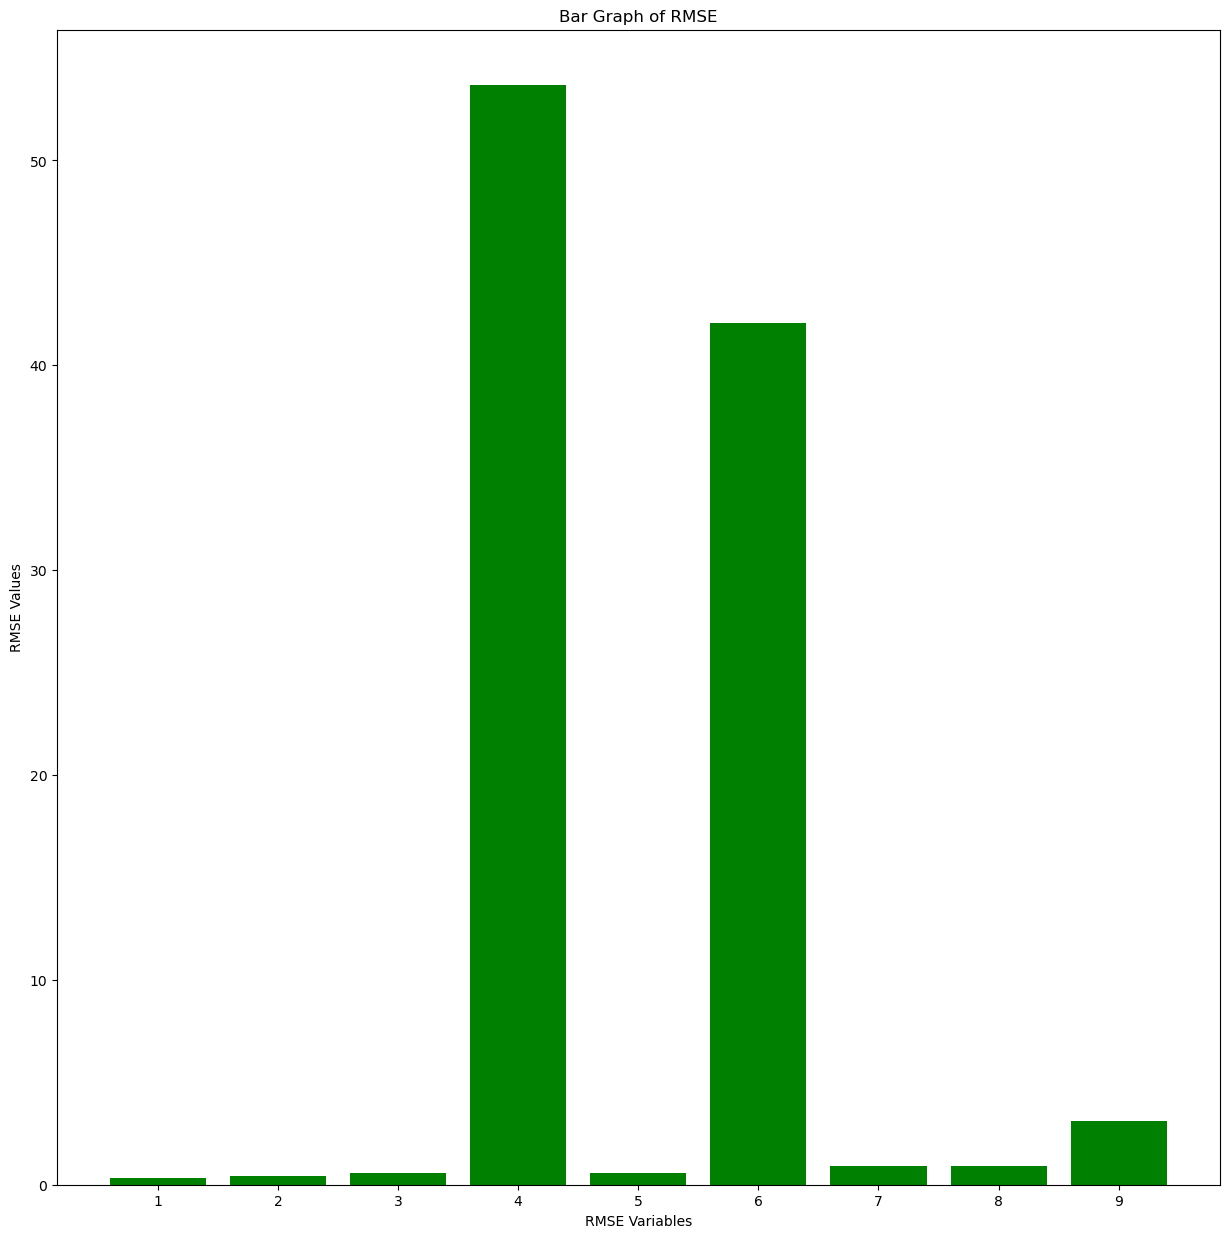

In [33]:
import matplotlib.pyplot as plt

rmse = [float(rmse1), rmse2, rmse4, rmse5, rmse6, rmse7, rmse8, rmse9, rmse10]
labels = ['1', '2', '3', '4', '5', '6', '7', '8', '9']

# Plotting the bar graph
plt.bar(labels, rmse, color='green')
plt.xlabel('RMSE Variables')
plt.ylabel('RMSE Values')
plt.title('Bar Graph of RMSE')
plt.show()

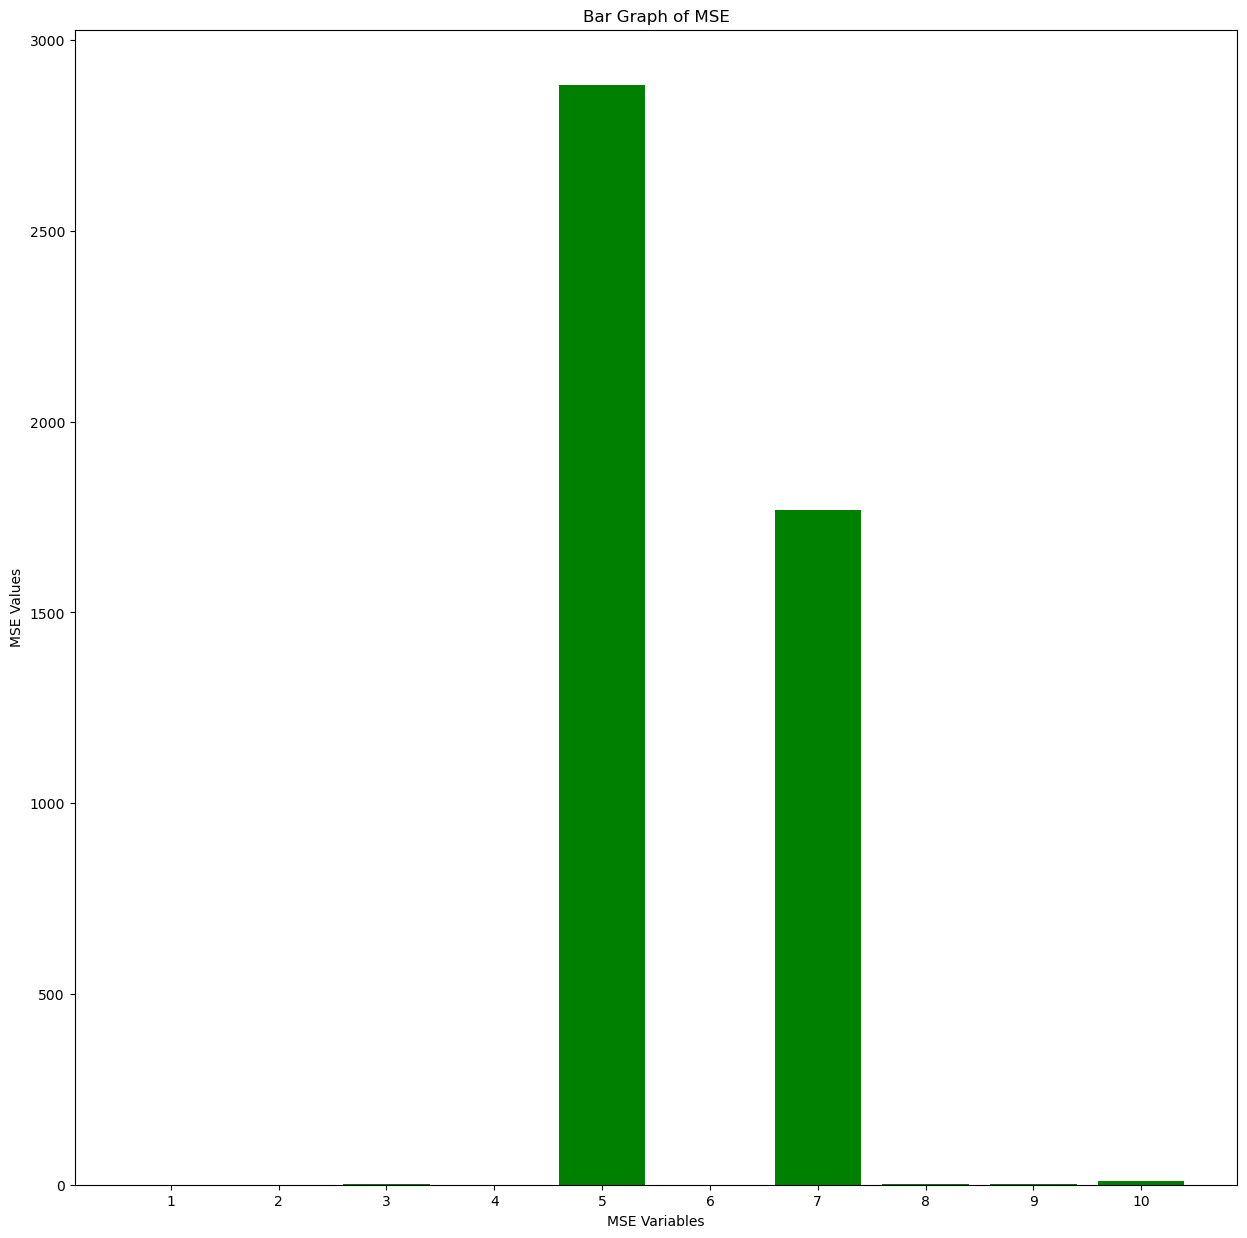

In [34]:
import matplotlib.pyplot as plt
mse = [float(mse1), mse2, mse3, mse4, mse5, mse6, mse7, mse8, mse9, mse10]
labels = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

# Plotting the bar graph
plt.bar(labels, mse, color='green')
plt.xlabel('MSE Variables')
plt.ylabel('MSE Values')
plt.title('Bar Graph of MSE')
plt.show()

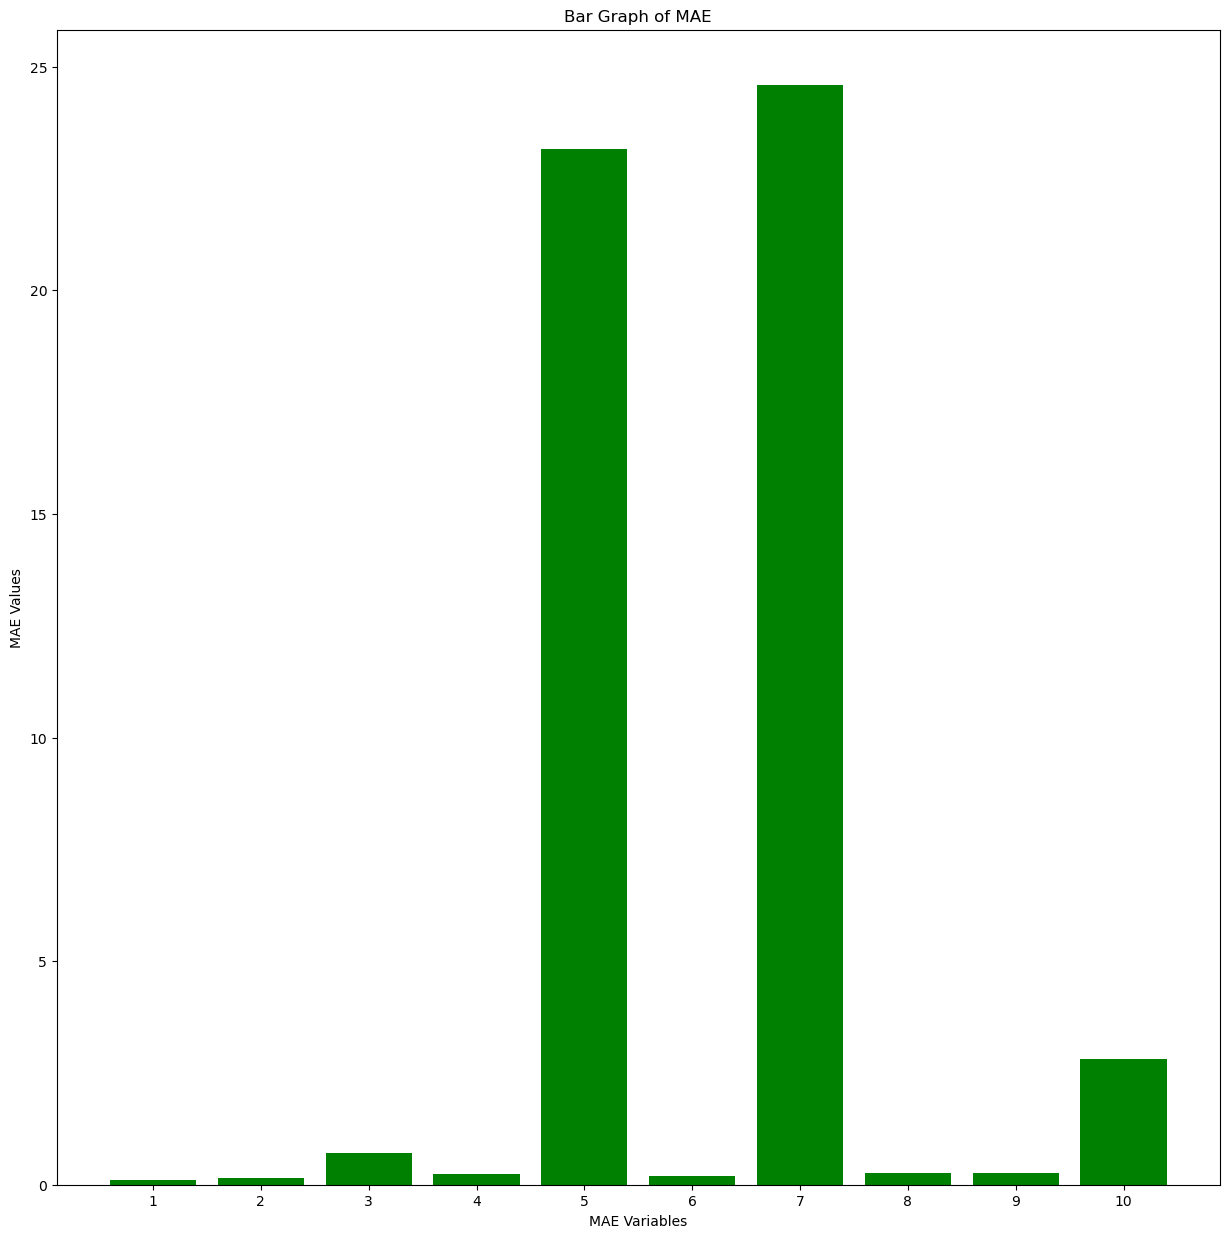

In [35]:
import matplotlib.pyplot as plt

mae = [float(mae1), mae2, mae3,mae4, mae5, mae6, mae7, mae8, mae9, mae10]

labels = ['1', '2','3', '4','5','6','7','8','9','10']

# Plotting the bar graph
plt.bar(labels, mae, color='green')
plt.xlabel('MAE Variables')
plt.ylabel('MAE Values')
plt.title('Bar Graph of MAE')
plt.show()

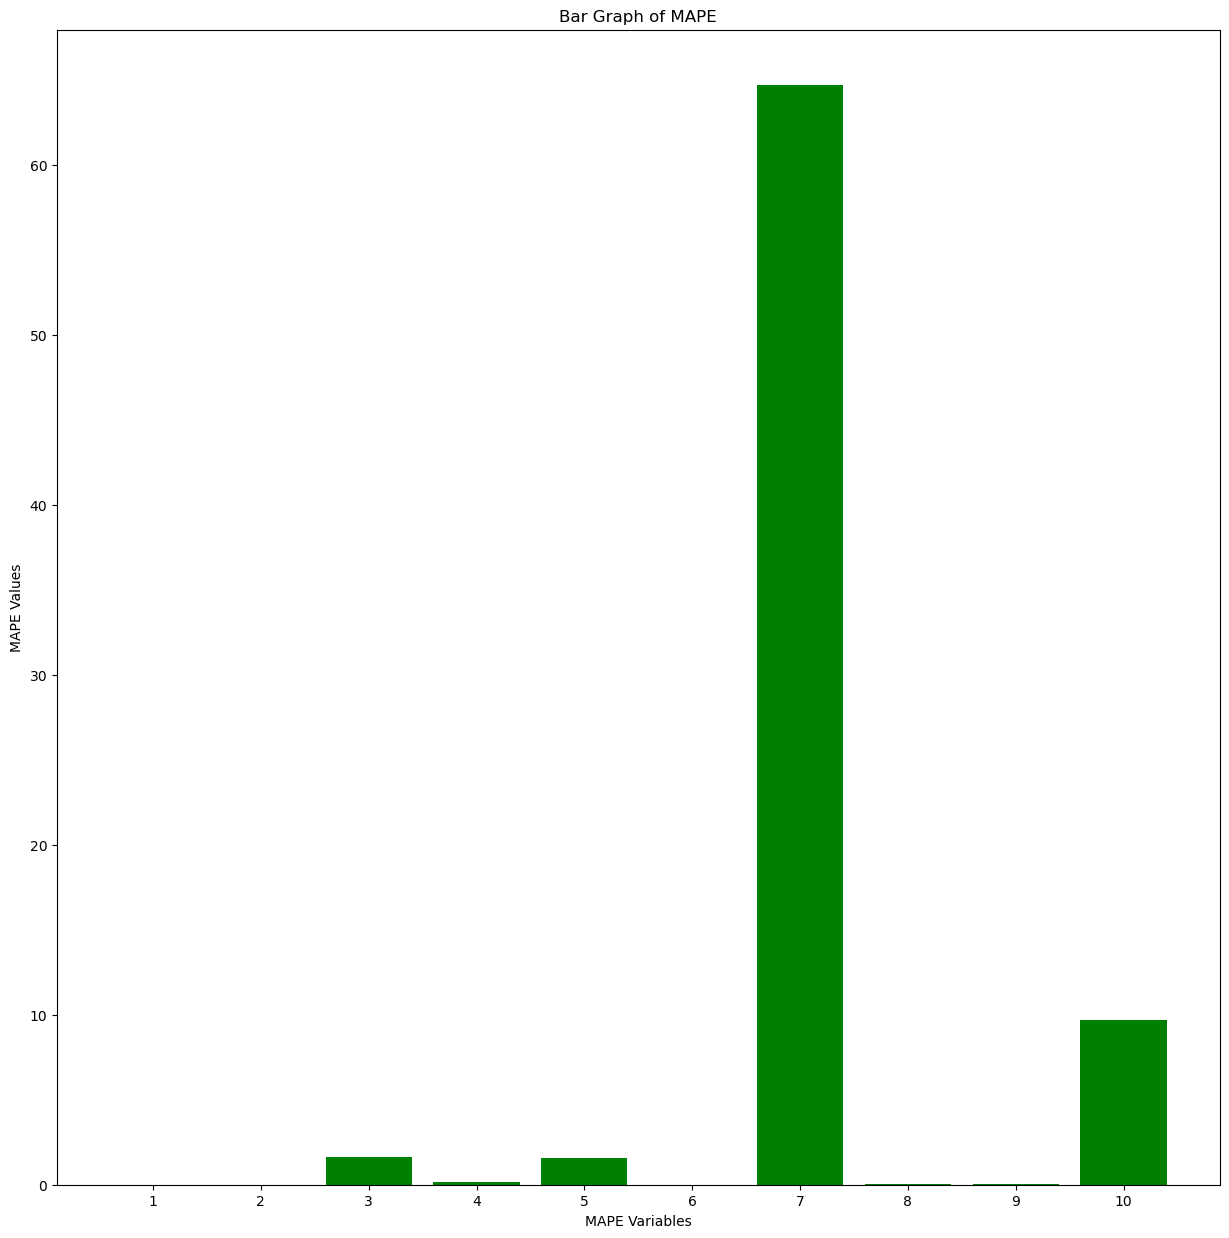

In [36]:
import matplotlib.pyplot as plt


mape = [float(mape1), mape2, mape3,mape4, mape5, mape6, mape7, mape8, mape9, mape10]
labels = ['1', '2','3', '4', '5', '6', '7', '8', '9', '10']

# Plotting the bar graph
plt.bar(labels, mape, color='green')
plt.xlabel('MAPE Variables')
plt.ylabel('MAPE Values')
plt.title('Bar Graph of MAPE')
plt.show()

### LSTM

In [37]:
df1=df.reset_index()['Close']

In [38]:
df1

0          0.128348
1          0.121652
2          0.112723
3          0.115513
4          0.118862
            ...    
11079    229.869995
11080    232.869995
11081    235.059998
11082    234.929993
11083    237.330002
Name: Close, Length: 11084, dtype: float64

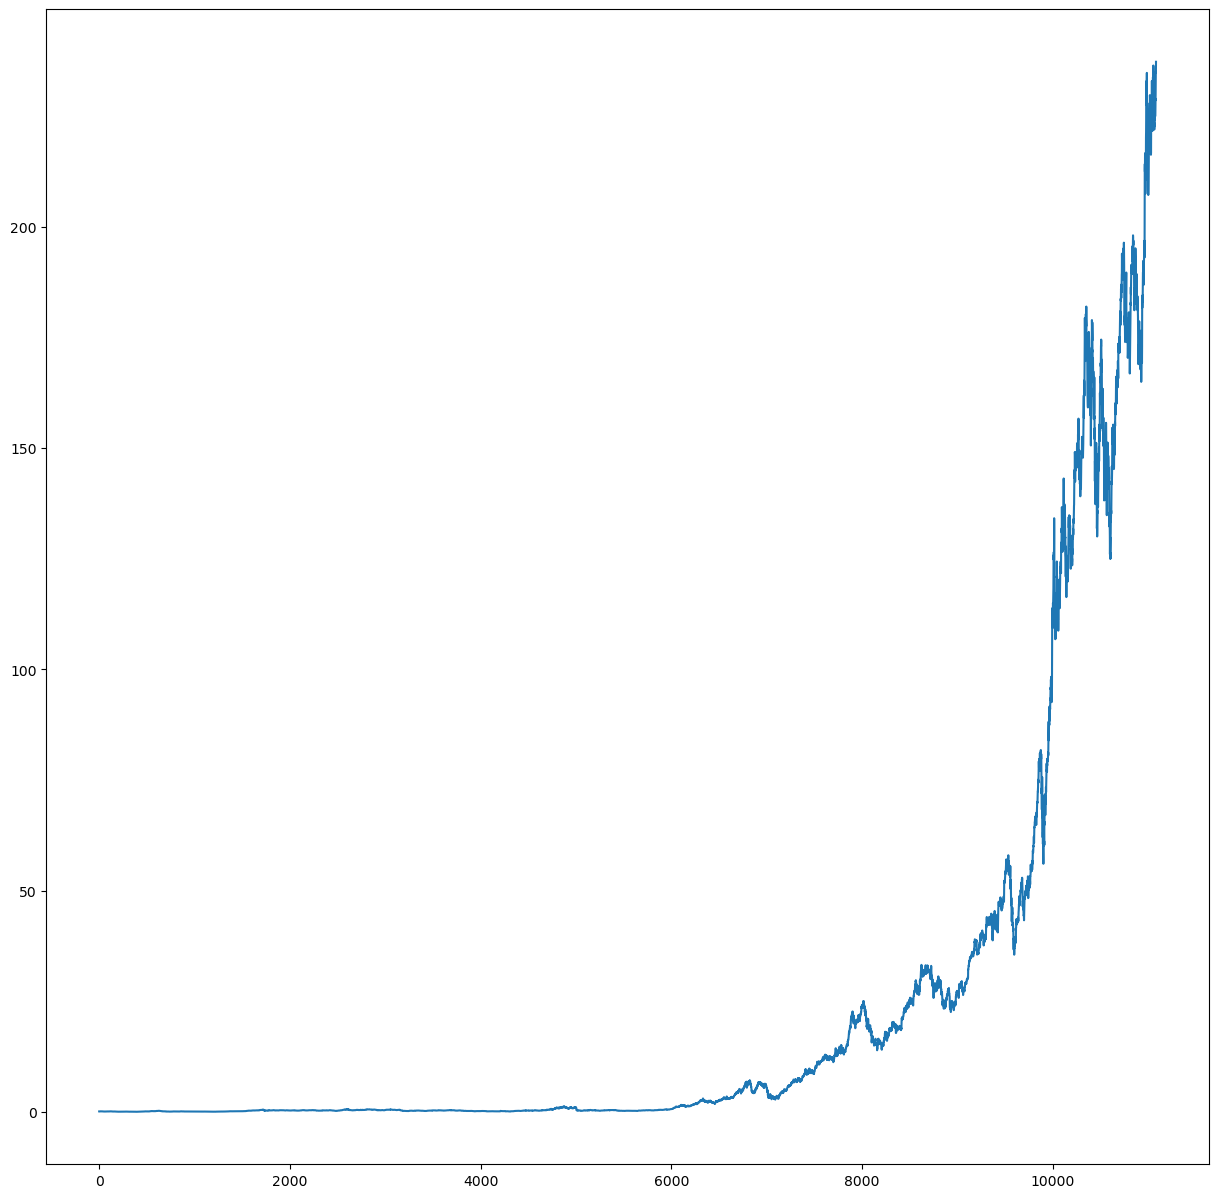

In [39]:
import matplotlib.pyplot as plt
plt.plot(df1)

### LSTM are sensitive to the scale of the data. so we apply MinMax scaler

In [41]:
import numpy as np

In [42]:
df1

0          0.128348
1          0.121652
2          0.112723
3          0.115513
4          0.118862
            ...    
11079    229.869995
11080    232.869995
11081    235.059998
11082    234.929993
11083    237.330002
Name: Close, Length: 11084, dtype: float64

In [43]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [44]:
print(df1)

[[3.33954375e-04]
 [3.05734687e-04]
 [2.68104181e-04]
 ...
 [9.90433262e-01]
 [9.89885367e-01]
 [1.00000000e+00]]


In [45]:
##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [46]:
training_size,test_size

(7204, 3880)

In [47]:
train_data

array([[0.00033395],
       [0.00030573],
       [0.0002681 ],
       ...,
       [0.02116163],
       [0.02123087],
       [0.02129107]])

In [48]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [49]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [50]:
print(X_train.shape), print(y_train.shape)

(7103, 100)
(7103,)


(None, None)

In [51]:
print(X_test.shape), print(ytest.shape)

(3779, 100)
(3779,)


(None, None)

In [52]:
# reshape input to be [samples, time steps, features] which is required for LSTM

X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [53]:
### Create the Stacked LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [56]:
model3=Sequential()
model3.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model3.add(LSTM(50,return_sequences=True))
model3.add(LSTM(50))
model3.add(Dense(1))
model3.compile(loss='mean_squared_error',optimizer='adam')

In [57]:
model3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                        │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_9 (LSTM)                        │ (None, 100, 50)             │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_10 (LSTM)                       │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model3.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 31s 227ms/step - loss: 1.8147e-05 - val_loss: 0.0093
Epoch 2/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 226ms/step - loss: 5.0573e-07 - val_loss: 0.0061
Epoch 3/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 226ms/step - loss: 5.3182e-07 - val_loss: 0.0052
Epoch 4/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - loss: 4.7307e-07 - val_loss: 0.0042
Epoch 5/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 231ms/step - loss: 4.2973e-07 - val_loss: 0.0029
Epoch 6/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 36s 185ms/step - loss: 4.2800e-07 - val_loss: 0.0052
Epoch 7/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 223ms/step - loss: 6.3346e-07 - val_loss: 0.0027
Epoch 8/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 22s 195ms/step - loss: 4.4431e-07 - val_loss: 0.0044
Epoch 9/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - loss: 3.7192e-07 - val_loss: 0.0027
Epoch 10/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - loss: 3.4528e-07 - val_loss: 0.0045
Epoch 11/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 20s 182ms/step - 

In [60]:
import tensorflow as tf

In [61]:
tf.__version__

'2.21.0'

In [62]:
### Lets Do the prediction and check performance metrics
train_predict=model3.predict(X_train)
test_predict=model3.predict(X_test)

222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step
119/119 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step


In [63]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [64]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
rmse = math.sqrt(mean_squared_error(y_train,train_predict))
rmse

1.5521656621876159

In [65]:
### Test Data RMSE
mse3 = math.sqrt(mean_squared_error(ytest,test_predict))
mse3

76.23994978781711

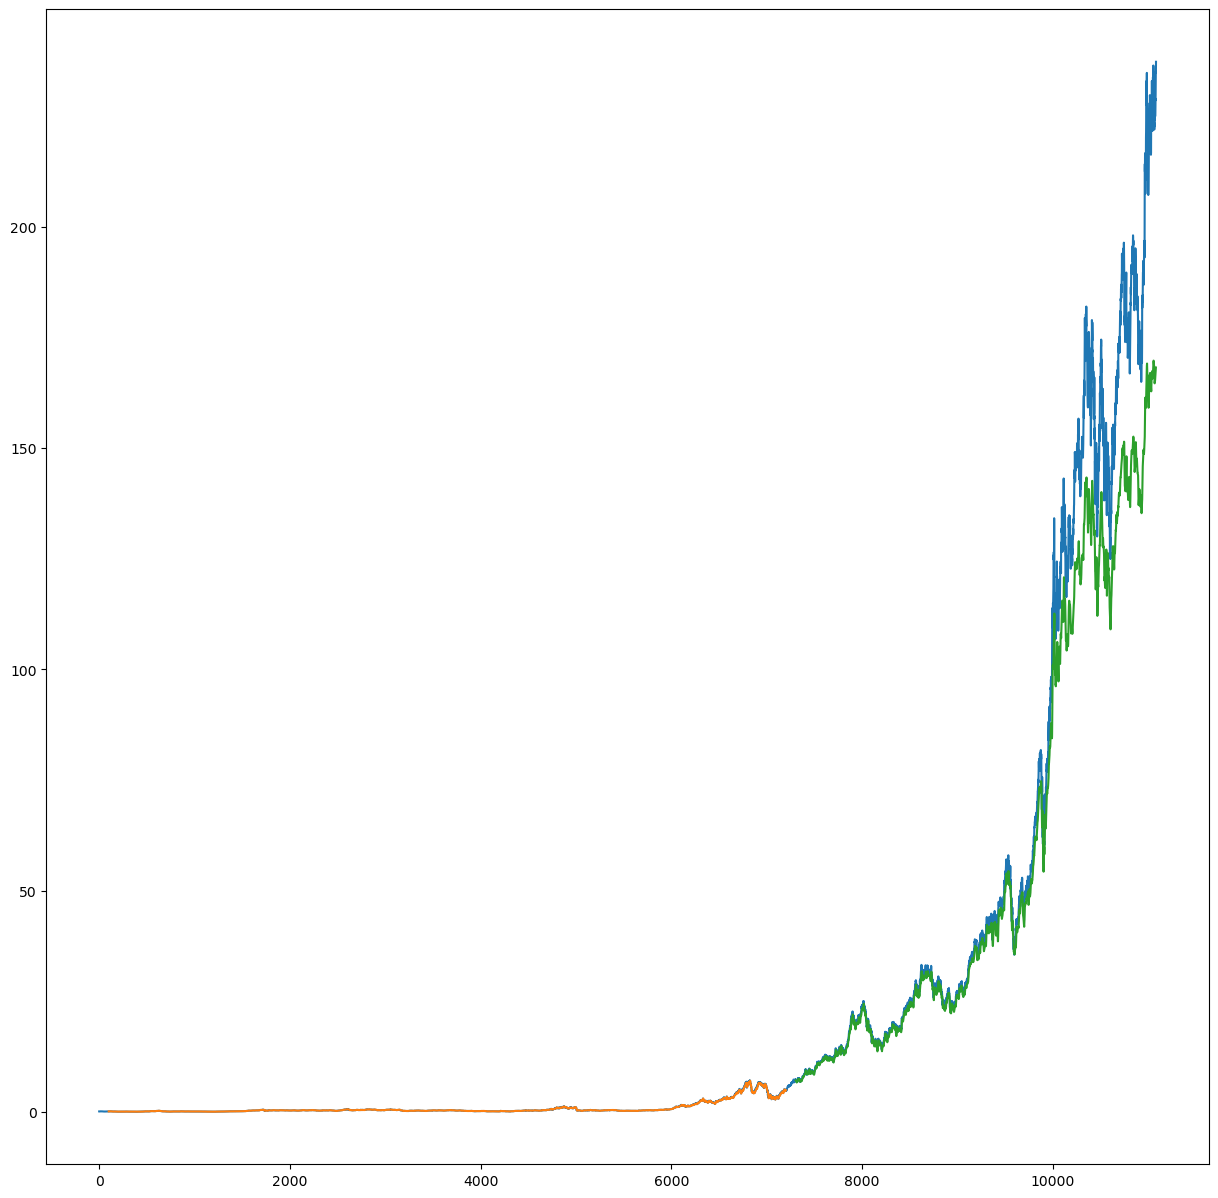

In [66]:
### Plotting

# shift train predictions for plotting

look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict

# shift test predictions for plotting

testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict

# plot baseline and predictions

plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [67]:
len(test_data)

3880

In [68]:
x_input=test_data[253:].reshape(1,-1)
x_input.shape

(1, 3627)

In [69]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [70]:
temp_input

[0.03721553919224347,
 0.038726702150821454,
 0.03863940559027258,
 0.038869696491046775,
 0.03851899501518569,
 0.03769266795178994,
 0.037832643890552284,
 0.03763998857779088,
 0.03740669133299307,
 0.03675646458325813,
 0.03770621258631565,
 0.03805992442675161,
 0.03877938554537177,
 0.0389178583079079,
 0.03881852028905952,
 0.039540991772254556,
 0.0390713828975328,
 0.03864241595484745,
 0.03851297428603594,
 0.03920534212348224,
 0.03921738358178174,
 0.03937542572854458,
 0.03918276639523192,
 0.038940438056709485,
 0.03919029029639347,
 0.03883808564852057,
 0.037450339613267505,
 0.03769116477977813,
 0.03728628075790617,
 0.03706652814341965,
 0.0377182580651664,
 0.03788382009253954,
 0.037403680968418195,
 0.03736755658930531,
 0.03678957859779615,
 0.035906058623814664,
 0.03635158056138618,
 0.03595873799781372,
 0.03616042842063659,
 0.036292880454022965,
 0.03638319139969797,
 0.037471412165291616,
 0.03774835769457829,
 0.038741757994247075,
 0.03859726450256121,
 0

In [72]:
import numpy as np
from numpy import array

lst_output = []
n_steps = 100
i = 0

while i < 30:

    # Take only the latest 100 observations
    x_input = np.array(temp_input[-n_steps:])

    print(f"{i} day input {x_input}")

    # Shape required by LSTM
    x_input = x_input.reshape((1, n_steps, 1))

    yhat = model3.predict(x_input, verbose=0)

    print()
    print(f"{i} day output {yhat}")
    print()

    # Add prediction to sequence
    temp_input.extend(yhat[0].tolist())

    # Keep only the most recent 100 values
    temp_input = temp_input[-n_steps:]

    lst_output.extend(yhat.tolist())

    i += 1

print(lst_output)

0 day input [0.95886734 0.97138409 0.98765173 0.98942184 0.96438821 0.94458041
 0.94512831 0.9436533  0.94807838 0.92081112 0.91638604 0.91836682
 0.91954685 0.92190691 0.93573018 0.92005256 0.92637418 0.88174354
 0.8731461  0.88406149 0.89876975 0.91111802 0.91655458 0.93231652
 0.93421299 0.94685623 0.95246141 0.95178709 0.95440001 0.95393642
 0.94605548 0.95579077 0.95722366 0.96080593 0.95431576 0.96822328
 0.96489392 0.93863814 0.93054647 0.93699452 0.93042004 0.93079932
 0.92742778 0.93817455 0.93863814 0.93750023 0.91145518 0.91343589
 0.92987215 0.96434603 0.96152238 0.95423146 0.95802441 0.95380999
 0.95865661 0.95979445 0.98175158 0.95313573 0.95553792 0.95085991
 0.95562222 0.93408656 0.95128138 0.96716968 0.96506247 0.95878303
 0.97458709 0.98533386 0.97660999 0.9781693  0.99018041 0.99641772
 0.99380481 0.97231127 0.97151058 0.97505068 0.98343732 0.98457523
 0.9695298  0.9518714  0.93922815 0.93543514 0.94150391 0.9384274
 0.95848799 0.95629654 0.94479115 0.94479115 0.9485

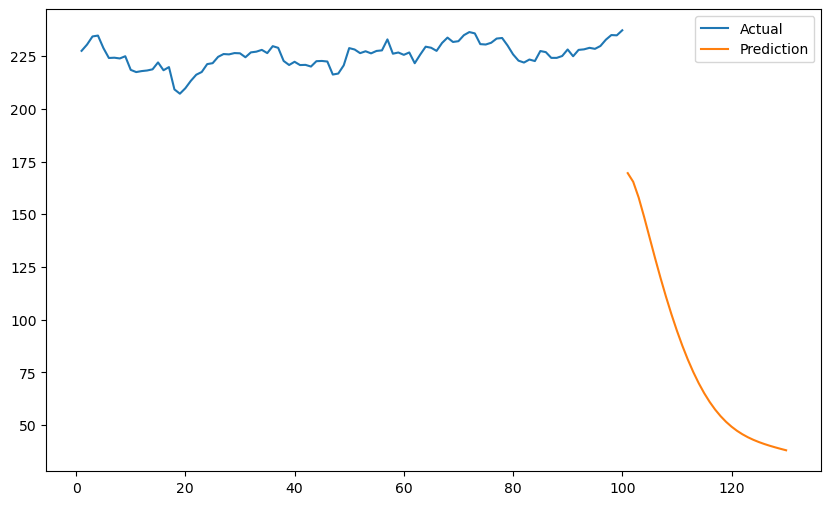

In [77]:
day_new = np.arange(1, 101)
day_pred = np.arange(101, 131)

actual = scaler.inverse_transform(df1[-100:])
predicted = scaler.inverse_transform(np.array(lst_output))

plt.figure(figsize=(10,6))
plt.plot(day_new, actual, label='Actual')
plt.plot(day_pred, predicted, label='Prediction')
plt.legend()
plt.show()

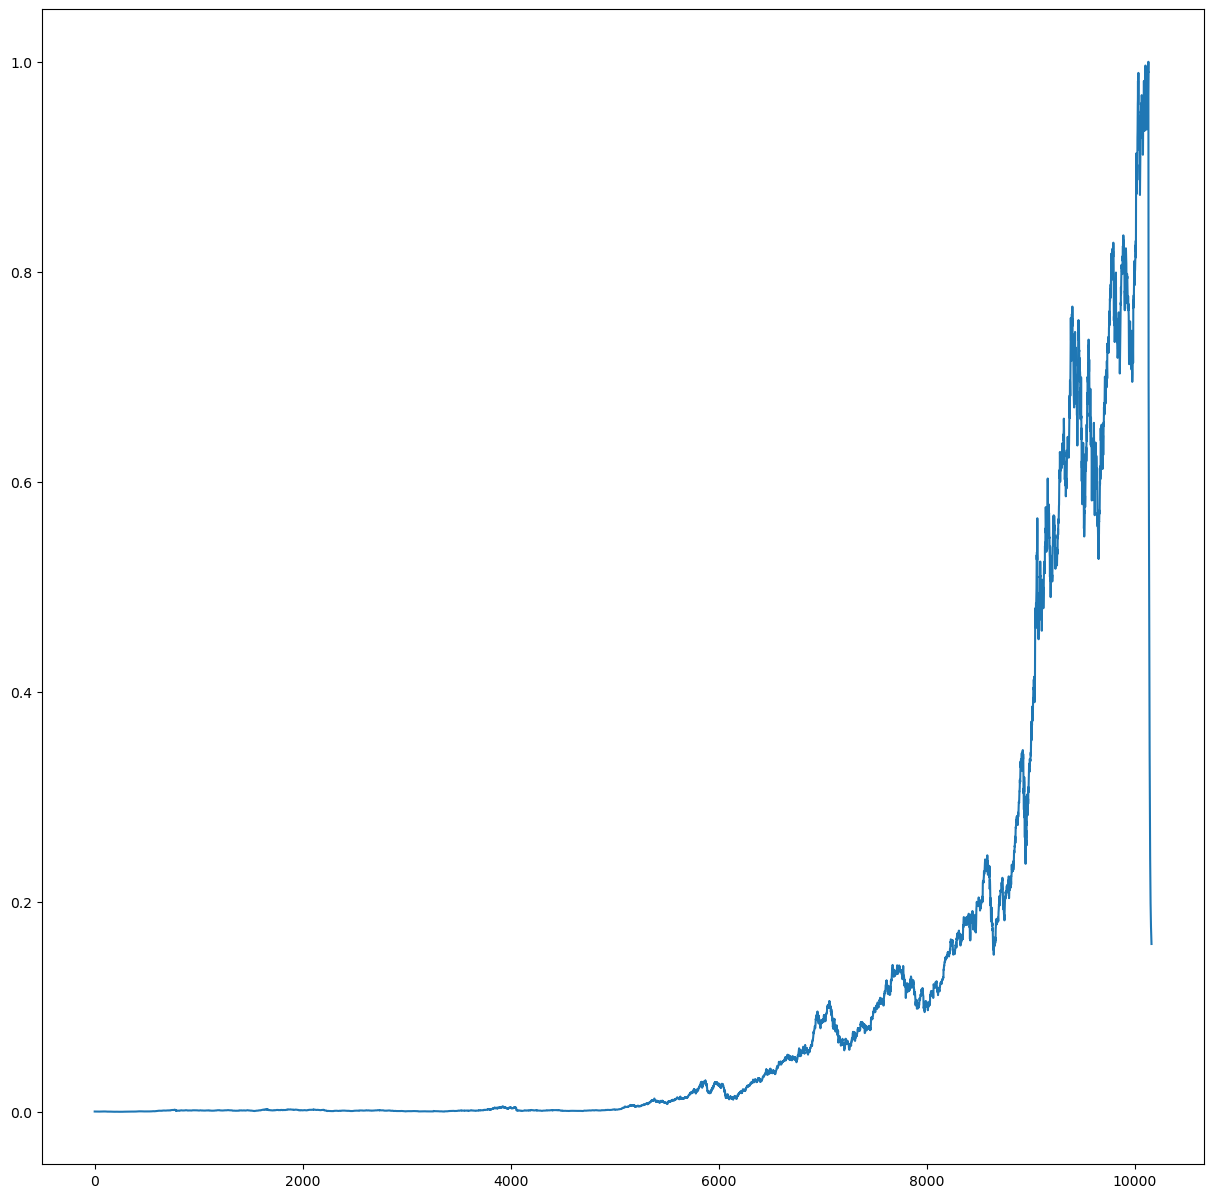

In [78]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[950:])

In [79]:
df3=scaler.inverse_transform(df3).tolist()

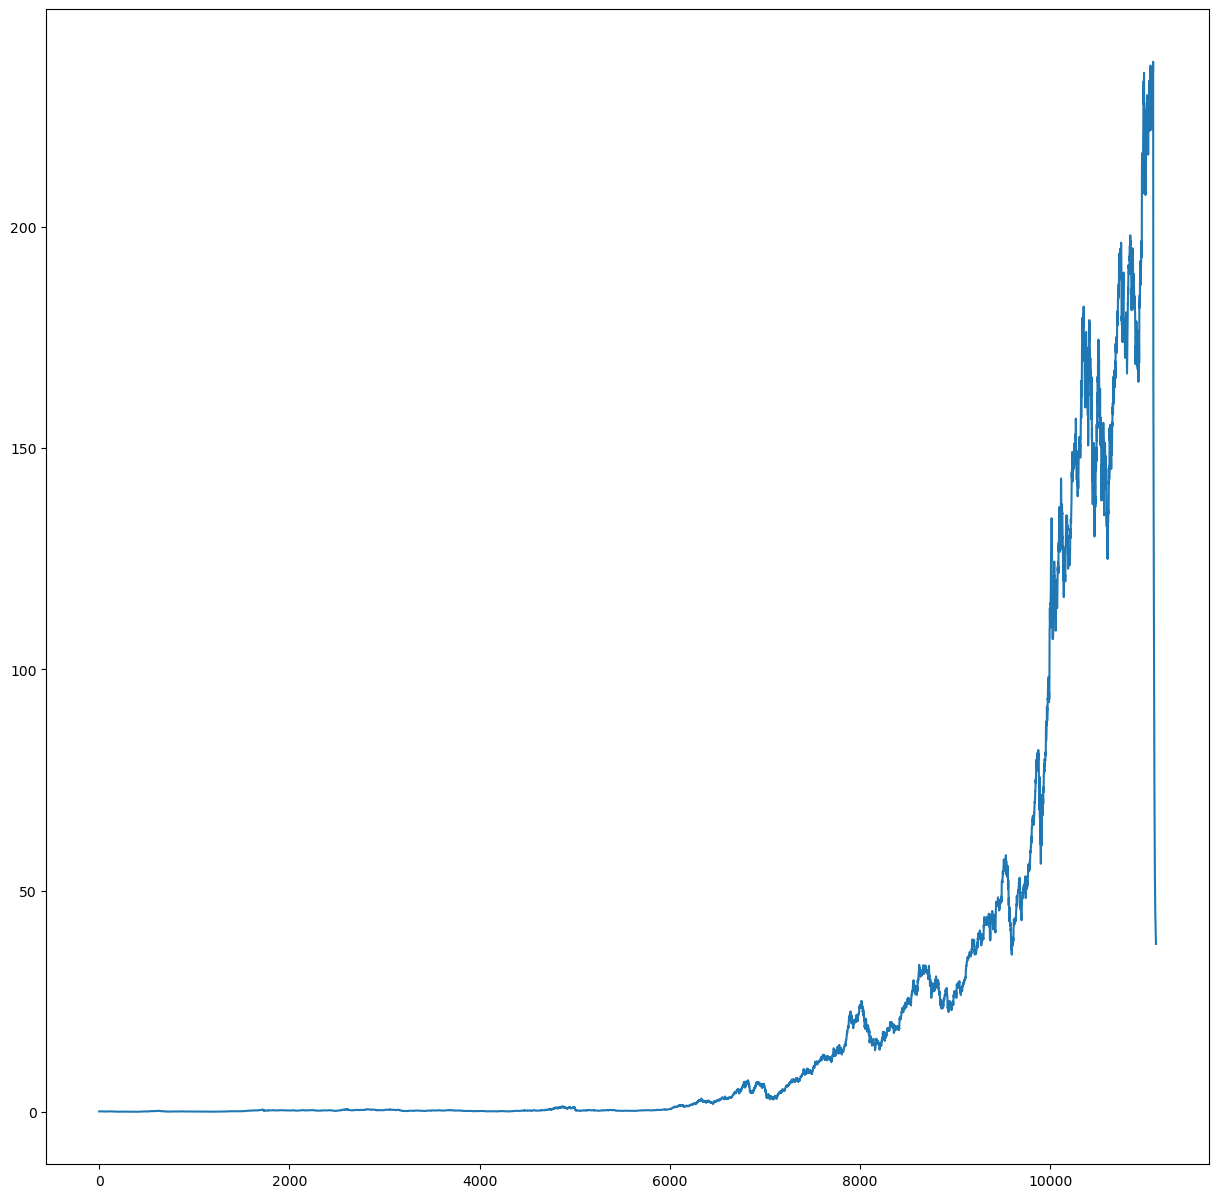

In [81]:
plt.plot(df3)